In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import imageio
import os

sns.set(style="whitegrid", font_scale=1.4)

def load_result(npz_path):
    return np.load(npz_path, allow_pickle=True)

def plot_overlay_profile(z, exact, pred, title, ylabel):
    plt.figure(figsize=(7,4))
    plt.plot(z, exact, 'o', ms=4, alpha=0.8, label="C-sim (Exact)")
    plt.plot(z, pred, '-', lw=2.5, label="PINN")
    plt.xlabel("z [m]")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [2]:
n0  = 1.0e16 * 15
T0  = 11604.0
t0  = 1.0e-8
m0  = 1.6605e-27
kB  = 1.3807e-23
QE  = 1.6022e-19

u0 = np.sqrt(kB*T0/m0)
l0 = u0 * t0        # length scale

In [4]:
EXPERIMENT_ROOT = Path("/home/dlee/code/Plasma/Argon_steady_New_data_2510/Steady_BC_Hard_12_colloc0_make_gif_gradnorm_updated/CKPT_SAVED")
npz_files = sorted(EXPERIMENT_ROOT.rglob("results_step*.npz"))
print("총 npz 개수:", len(npz_files))

# step setting
target_steps = [5000,10000,15000,20000,25000,30000,35000,40000,45000,50000,55000,60000,65000,70000,75000,80000,85000,90000,95000,100000]

def get_step_from_npz(path):
    with np.load(path, allow_pickle=True) as d:
        return int(d["meta__step"])
    
selected_paths = []
for p in npz_files:
    s = get_step_from_npz(p)
    if s in target_steps:
        selected_paths.append(p)

print("선택된 step:", [get_step_from_npz(p) for p in selected_paths])

frames = []
frame_dir = Path("./gif_frames")
frame_dir.mkdir(exist_ok=True)

총 npz 개수: 125
선택된 step: [5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000, 100000]


In [5]:
# 각 profile별 x/y 범위 (네가 원하는 값으로 채우면 됨)
AX_LIMS = {
    "ni": {   # Ion density
        "x": (0.0, 0.10),     # z [m]
        "y": (1.1e17, 4.3e17),      # n_i 범위
    },
    "Te": {  # Electron temperature
        "x": (0.0, 0.10),
        "y": (2.425e4, 2.575e4),
    },
    "E": {   # Electric field
        "x": (0.0, 0.10),
        "y": (-0.020, 0.020),
    },
    "G": {   # Ion flux
        "x": (0.0, 0.10),
        "y": (-0.22, 0.20),
    },
}

In [6]:
def save_frame_subplots(data, out_path=None):
    z = data["z_SI"]   # already dimensional

    # nondim values
    ni_sim, ni_p = data["ni_sim"], data["ni_pinn"]
    Te_sim, Te_p = data["Te_sim"], data["Te_pinn"]
    E_sim,  E_p  = data["E_sim"],  data["E_pinn"]
    G_sim,  G_p  = data["G_sim"],  data["G_pinn"]

    # =========  🔥 Inverse nondimensionalization  =========
    ni_sim = ni_sim * n0
    ni_p   = ni_p   * n0

    Te_sim = Te_sim * T0
    Te_p   = Te_p   * T0

    # E, G는 이미 dimensional 혹은 nondim이지만 네 axis 범위가 그대로 SI 기준이라면 그대로 사용
    # 필요하면 scale 추가 가능
    E_sim = E_sim
    E_p   = E_p
    G_sim = G_sim
    G_p   = G_p
    # ======================================================

    step = int(data["meta__step"])

    fig, axes = plt.subplots(2, 2, figsize=(12,12))
    ax11, ax12, ax21, ax22 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

    # 1) n_i
    ax11.plot(z, ni_sim, 'o', ms=3, label="exact")
    ax11.plot(z, ni_p,   '-', lw=2, label="PINN")
    ax11.set_title("Ion Density")
    ax11.set_ylabel(r"$n_i\;[\mathrm{m^{-3}}]$")
    ax11.grid(alpha=0.3)
    ax11.set_xlim(*AX_LIMS["ni"]["x"])
    ax11.set_ylim(*AX_LIMS["ni"]["y"])

    # 2) T_e
    ax12.plot(z, Te_sim, 'o', ms=3, label="exact")
    ax12.plot(z, Te_p,   '-', lw=2, label="PINN")
    ax12.set_title("Electron Temperature")
    ax12.set_ylabel(r"$T_e\;[\mathrm{K}]$")
    ax12.grid(alpha=0.3)
    # 🔥 여기 추가: y축을 항상 과학 표기 + 1e4 offset으로
    ax12.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # 항상 sci 사용
    ax12.yaxis.get_offset_text().set_fontsize(12)  # 위에 뜨는 '1e4' 글자 크기 조정
    ax12.set_xlim(*AX_LIMS["Te"]["x"])
    ax12.set_ylim(*AX_LIMS["Te"]["y"])

    # 3) E
    ax21.plot(z, E_sim, 'o', ms=3, label="exact")
    ax21.plot(z, E_p,   '-', lw=2, label="PINN")
    ax21.set_title("Electric Field")
    ax21.set_xlabel("z [m]")
    ax21.set_ylabel(r"$E$")   # unit optional
    ax21.grid(alpha=0.3)
    ax21.set_xlim(*AX_LIMS["E"]["x"])
    ax21.set_ylim(*AX_LIMS["E"]["y"])

    # 4) Γ
    ax22.plot(z, G_sim, 'o', ms=3, label="exact")
    ax22.plot(z, G_p,   '-', lw=2, label="PINN")
    ax22.set_title("Ion Flux")
    ax22.set_xlabel("z [m]")
    ax22.set_ylabel(r"$\Gamma$")
    ax22.grid(alpha=0.3)
    ax22.set_xlim(*AX_LIMS["G"]["x"])
    ax22.set_ylim(*AX_LIMS["G"]["y"])

    for ax in [ax11, ax12, ax21, ax22]:
        ax.set_box_aspect(1)

    handles, labels = ax11.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center",
               ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f"Learned solution : step {step:06d}", fontsize=18, y=0.94)
    plt.tight_layout(rect=[0, 0.0, 1, 0.95])

    if out_path is None:
        plt.show()
    else:
        plt.savefig(out_path)
        plt.close()

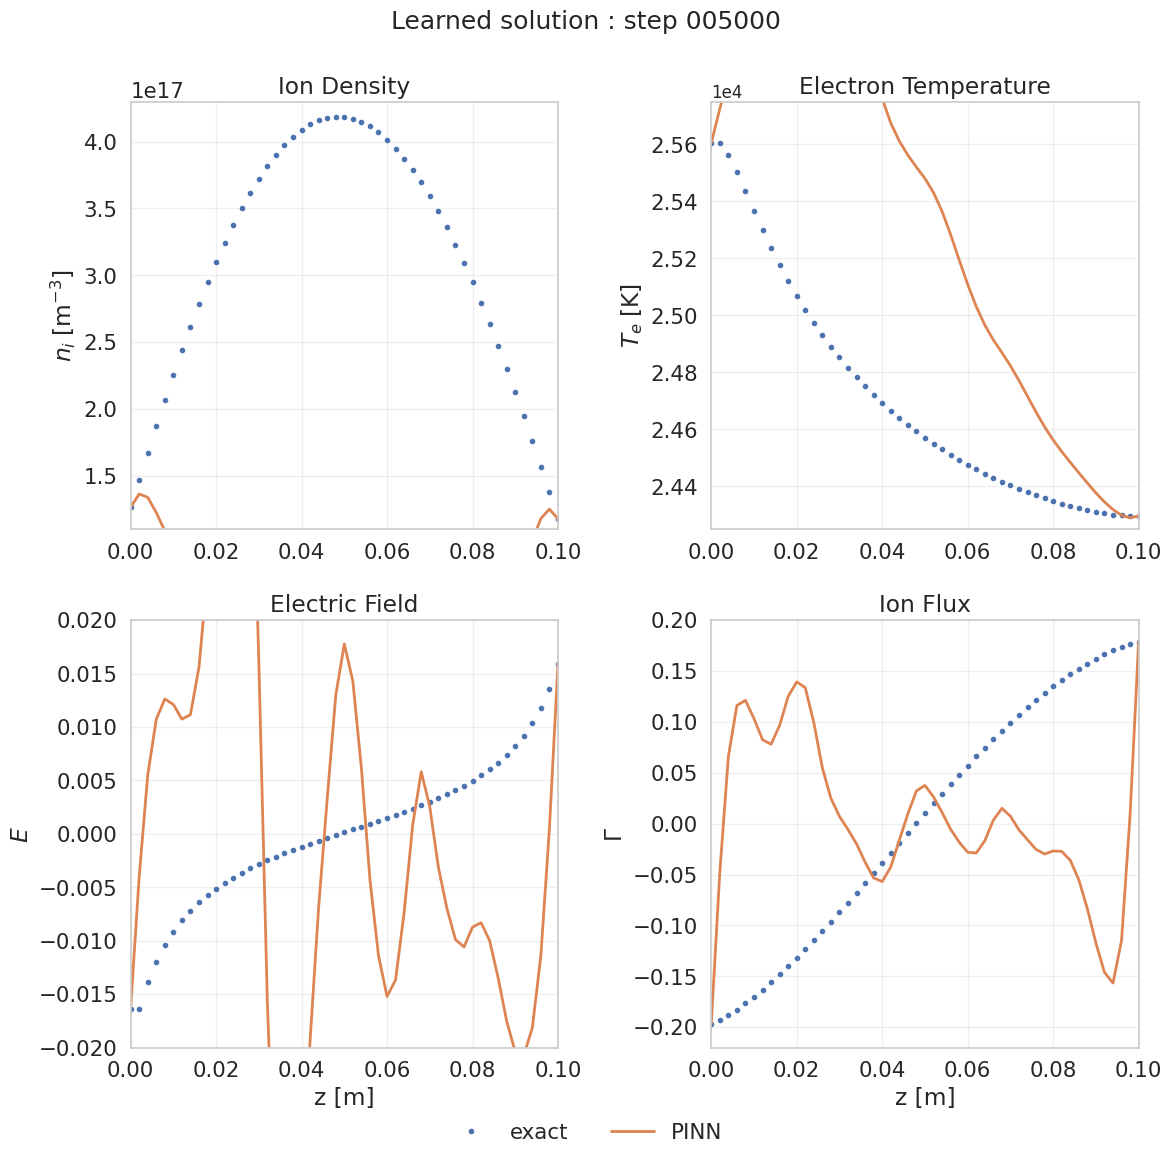

In [7]:
# 🔍 첫 프레임 미리 확인
preview_data = load_result(selected_paths[0])
save_frame_subplots(preview_data, out_path=None)  # 저장 없이 ipynb에 표시

In [8]:
# subplot for total (2,2)
frames = []
for i, path in enumerate(selected_paths):
    data = load_result(path)
    frame_path = frame_dir / f"frame_subplot_{i:04d}.png"
    save_frame_subplots(data, frame_path)
    #plot_from_npz_subplots(data)
    frames.append(imageio.imread(frame_path))

imageio.mimsave("gif_subplot_nondim.gif", frames, fps=5)

/tmp/ipykernel_2178828/3141630700.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))
